# 02 — Baseline Model

Build the simplest possible fraud detector first. This gives us a score to beat in every notebook that follows. If a fancier model cannot beat this, it is not worth using


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve,
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TEST_SIZE    = 0.2
THRESHOLD    = 0.5

## 1. Load & minimal feature prep

In [5]:
df = pd.read_csv('../data/raw/creditcard.csv')

# Insights from notebook 01: log-scale Amount, derive hour-of-day from Time
df['log_amount']  = np.log1p(df['Amount'])
df['hour_of_day'] = (df['Time'] // 3600) % 24
df = df.drop(columns=['Time', 'Amount'])

print(f"Dataset: {df.shape[0]:,} rows, {df.shape[1]} features")
print(f"Fraud rate: {df['Class'].mean()*100:.4f}%")

Dataset: 284,807 rows, 31 features
Fraud rate: 0.1727%


## 2. Train / test split

In [7]:
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape[0]:,} rows  |  Test: {X_test_sc.shape[0]:,} rows")
print(f"Train fraud count : {y_train.sum()}")
print(f"Test  fraud count : {y_test.sum()}")

Train: 227,845 rows  |  Test: 56,962 rows
Train fraud count : 394
Test  fraud count : 98


## 3. Baseline — Logistic Regression

`class_weight='balanced'` is the only imbalance handling here.
Notebook 03 will add SMOTE on top of this.

In [9]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs',
)
lr.fit(X_train_sc, y_train)

y_prob = lr.predict_proba(X_test_sc)[:, 1]
y_pred = (y_prob >= THRESHOLD).astype(int)

print("Model trained.")

Model trained.


## 4. Metrics

In [11]:
prauc   = average_precision_score(y_test, y_prob)
rocauc  = roc_auc_score(y_test, y_prob)
prec    = precision_score(y_test, y_pred)
rec     = recall_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)

print(f"PR-AUC    : {prauc:.4f}")
print(f"ROC-AUC   : {rocauc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1        : {f1:.4f}")

PR-AUC    : 0.7129
ROC-AUC   : 0.9710
Precision : 0.0554
Recall    : 0.9082
F1        : 0.1045


## 5. Confusion matrix

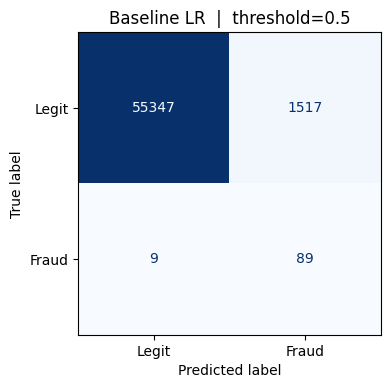

In [13]:
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Legit', 'Fraud']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Baseline LR  |  threshold={THRESHOLD}')
plt.tight_layout()
plt.savefig('../reports/figures/02_confusion_matrix.png')
plt.show()

## 6. PR curve and ROC curve

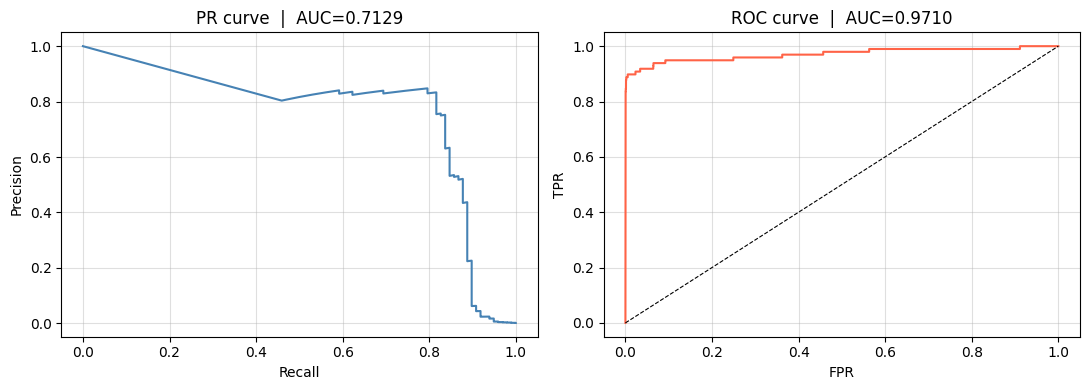

In [15]:
prec_curve, rec_curve, _  = precision_recall_curve(y_test, y_prob)
fpr, tpr, __              = roc_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(rec_curve, prec_curve, color='steelblue', lw=1.5)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title(f'PR curve  |  AUC={prauc:.4f}')
axes[0].grid(True, alpha=0.4)

axes[1].plot(fpr, tpr, color='tomato', lw=1.5)
axes[1].plot([0,1],[0,1], 'k--', lw=0.8)
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].set_title(f'ROC curve  |  AUC={rocauc:.4f}')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('../reports/figures/02_pr_roc_curves.png')
plt.show()

## 7. Save model and scaler

In [17]:
joblib.dump(lr,     '../models/baseline_lr.joblib')
joblib.dump(scaler, '../models/baseline_scaler.joblib')
print("Saved: models/baseline_lr.joblib")
print("Saved: models/baseline_scaler.joblib")

Saved: models/baseline_lr.joblib
Saved: models/baseline_scaler.joblib


## 8. Summary

In [19]:
baseline_results = {
    'model'    : 'LogisticRegression (balanced)',
    'threshold': THRESHOLD,
    'pr_auc'   : prauc,
    'roc_auc'  : rocauc,
    'precision': prec,
    'recall'   : rec,
    'f1'       : f1,
}

print("=" * 55)
print("BASELINE RESULTS — saved ===")
for k, v in baseline_results.items():
    if isinstance(v, float):
        print(f"{k:20s}: {v:.4f}")
    else:
        print(f"{k:20s}: {v}")
print(f"\nNext: notebook 03 - tackle imbalance properly with SMOTE")
print(f"Target: beat PR-AUC of {prauc:.4f}")

BASELINE RESULTS — saved ===
model               : LogisticRegression (balanced)
threshold           : 0.5000
pr_auc              : 0.7129
roc_auc             : 0.9710
precision           : 0.0554
recall              : 0.9082
f1                  : 0.1045

Next: notebook 03 - tackle imbalance properly with SMOTE
Target: beat PR-AUC of 0.7129
